In [8]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import curve_fit

In [9]:
sz = qt.sigmaz()
sx = qt.sigmax()
s_m = qt.sigmam().dag() # lowering operator from state 1 to state 0. State 0 is ground state.
s_p = qt.sigmam() # raising operator from state 0 to state 1. State 0 is ground state.

def evolve_state(initial_rho, times, expect_ops = None, jump_ops = None):
    H = 0*sz # no Hamiltonian
    result = qt.mesolve(H, initial_rho, times, c_ops=jump_ops, e_ops=expect_ops)
    return result

def projector_onto_states(states):
    # states: list of Qobj state vectors
    P = 0 * (states[0] * states[0].dag())   # zero operator with correct type/dims
    for psi in states:
        P += psi * psi.dag()
    return P

def fit(t, A, T, C):
    return A * np.exp(-t/T) + C

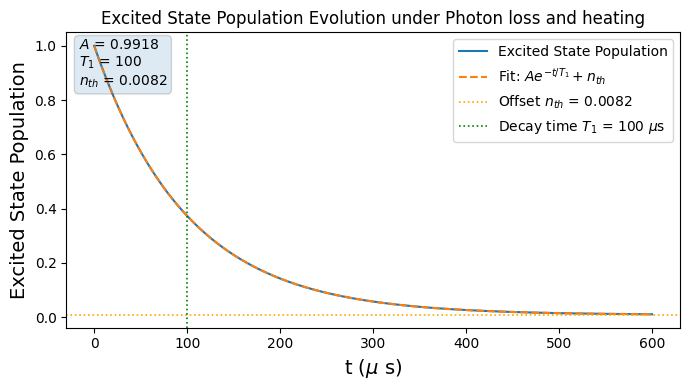

In [21]:
n_th = 0.0082 # mean thermal photon number
T1 = 100 # T1 time in us

state_0 = qt.basis(2, 0) # ground state
state_1 = qt.basis(2, 1) # excited state

gamma_loss = 1/T1 * (1 - n_th) # photon loss rate
gamma_gain = 1/T1 * n_th # photon gain rate

tau = np.linspace(0, 600, 10000) # units of T1

result = evolve_state(projector_onto_states([state_1]), tau, expect_ops=projector_onto_states([state_1]), jump_ops=[np.sqrt(gamma_loss)*s_m, np.sqrt(gamma_gain)*s_p]) # start in excited state, evolve under photon loss and gain

expect = result.expect[0]

# initial guesses
C0 = expect[-1]
A0 = expect[0] - C0
T0 = tau[-1]    
p0 = [A0, T0, C0]

# bounds for A, T, C: A > 0, T > 0, 0 < C < 1
bounds = ([0.0, 0.0, 0.0], [2.0, np.inf, 1.0])

# Fit the data to the model
popt, _ = curve_fit(fit, tau, expect, p0=p0, bounds=bounds)
A_fit, T_fit, C_fit = popt

fit_curve = fit(tau, *popt) # compute the fitted curve for plotting

plt.figure(figsize=(7, 4))
plt.plot(tau, expect, label='Excited State Population')
plt.plot(tau, fit_curve, '--', label=r'Fit: $A e^{-t/T_1} + n_{{th}}$')
plt.axhline(C_fit, linestyle=':', linewidth=1.2, label=rf'Offset $n_{{th}}$ = {C_fit:.4g}', color='orange')
plt.axvline(T_fit, linestyle=':', linewidth=1.2, label=rf'Decay time $T_1$ = {T_fit:.4g} $\mu$s', color='green')

txt = (
    rf"$A$ = {A_fit:.4g}" "\n"
    rf"$T_1$ = {T_fit:.4g}" "\n"
    rf"$n_{{th}}$ = {C_fit:.4g}"
)
plt.text(
    0.02, 0.98, txt,
    transform=plt.gca().transAxes,
    va='top', ha='left',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.xlabel(r't ($\mu$ s)', fontsize=14)
plt.ylabel('Excited State Population', fontsize=14)
plt.title(r'Excited State Population Evolution under Photon loss and heating')
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
!jupyter nbconvert "P4.ipynb" --to html
!open "P4.html"

[NbConvertApp] Converting notebook P4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 343541 bytes to P4.html
